core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


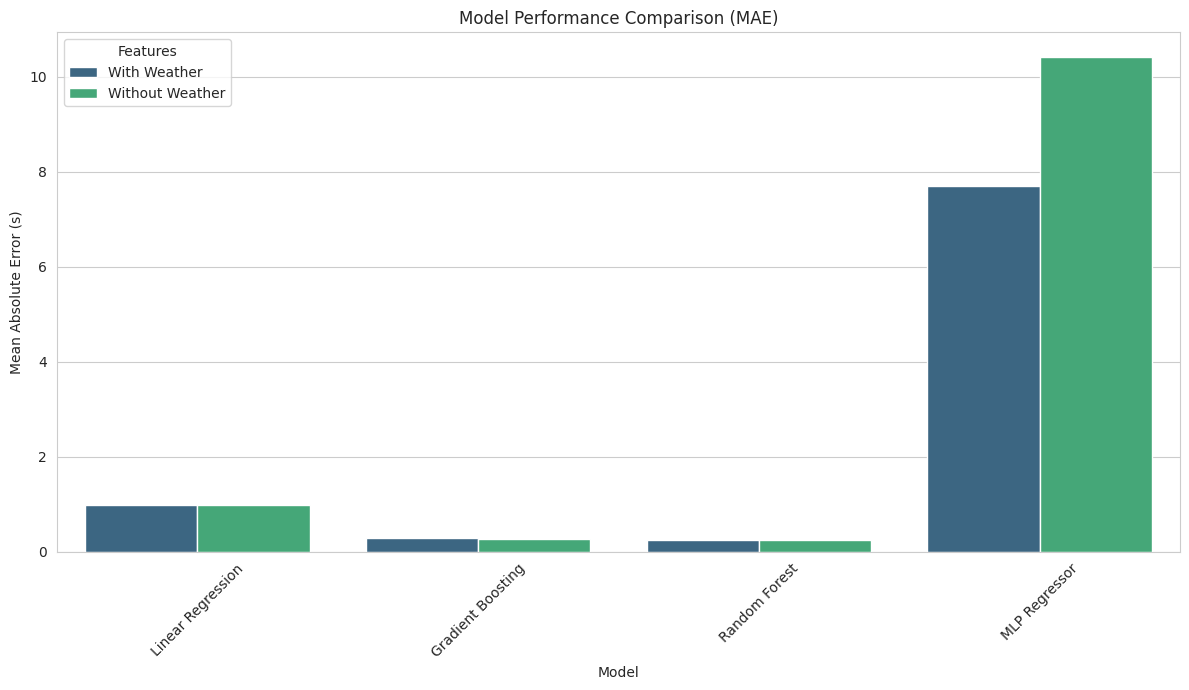


🏆 Best Performing Model: Random Forest (Without Weather) with MAE: 0.24s 🏆

🏁 Predicted 2025 Bahrain GP Winner (using best model) 🏁

   Driver  PredictedRaceTime (s)
0     VER              96.798906
5     HAM              96.998651
9     SAI              97.089959
1     NOR              97.194715
3     LEC              97.205356
2     PIA              97.248856
4     RUS              97.256088
7     ALO              97.950082
12    STR              97.993975
10    HUL              98.324640
6     GAS              98.422854
8     TSU              98.447489
11    OCO              98.602149


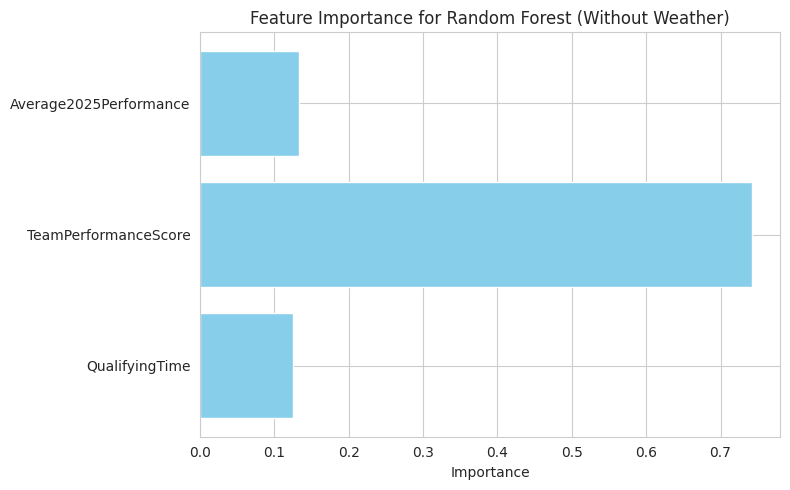

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



📡 Fetching actual 2025 Bahrain GP race results...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


⚠️  Some drivers didn't finish - estimating their race times...
✅ Successfully loaded 2025 Bahrain GP results!
   Race winner: PIA

🔍 PREDICTION vs ACTUAL RESULTS COMPARISON 🔍

📊 Overall Prediction Accuracy:
Average Position Error: 5.62 positions
Average Time Error: 1354.73 seconds
Median Position Error: 5 positions
Median Time Error: 69.01 seconds

🏆 Winner Prediction:
Predicted Winner: VER
Actual Winner: PIA
Correct Winner Prediction: ❌ NO

🥉 Top 3 Prediction:
Predicted Top 3: ['HAM', 'SAI', 'VER']
Actual Top 3: ['NOR', 'PIA', 'RUS']
Correctly Predicted in Top 3: 0/3 drivers
Biggest Prediction Miss (Underestimated): PIA (+17.0 points)
Biggest Prediction Miss (Overestimated): VER (-17.0 points)

Detailed driver comparison:

   Driver  PredictedPosition  ActualPosition  PositionDifference  \
3     NOR                  4               3                   1   
4     LEC                  5               4                   1   
1     HAM                  2               5                 

In [ ]:
import fastf1
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer 
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns

fastf1.Cache.enable_cache("/kaggle/working/")


session_2024 = fastf1.get_session(2024, "Bahrain", "R")
session_2024.load()
laps_2024 = session_2024.laps[["Driver", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]].copy()
laps_2024.dropna(inplace=True)

for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    laps_2024[f"{col} (s)"] = laps_2024[col].dt.total_seconds()


sector_times_2024 = laps_2024.groupby("Driver").agg({
    "Sector1Time (s)": "mean",
    "Sector2Time (s)": "mean",
    "Sector3Time (s)": "mean"
}).reset_index()

sector_times_2024["TotalSectorTime (s)"] = (
    sector_times_2024["Sector1Time (s)"] +
    sector_times_2024["Sector2Time (s)"] +
    sector_times_2024["Sector3Time (s)"]
)


qualifying_2025 = pd.DataFrame({
    "Driver": ["VER", "NOR", "PIA", "LEC", "RUS", "HAM", "GAS", "ALO", "TSU", "SAI", "HUL", "OCO", "STR"],
    "QualifyingTime (s)": [90.423, 90.267, 89.841, 90.175, 90.009, 90.772, 90.216, 91.886, 91.303, 90.680, 92.067, 91.886, 92.283]
})

average_2025 = {
    "VER": 90.5, "NOR": 91.0, "PIA": 91.2, "LEC": 90.9, "RUS": 91.1, 
    "HAM": 90.8, "GAS": 91.3, "ALO": 91.5, "TSU": 91.6, "SAI": 91.4,
    "HUL": 92.0, "OCO": 91.9, "STR": 92.1
}

driver_wet_performance = {
    "VER": 0.975196, "HAM": 0.976464, "LEC": 0.975862, "NOR": 0.978179, "ALO": 0.972655,
    "RUS": 0.968678, "SAI": 0.978754, "TSU": 0.996338, "OCO": 0.981810, "GAS": 0.978832, "STR": 0.979857
}
qualifying_2025["WetPerformanceFactor"] = qualifying_2025["Driver"].map(driver_wet_performance)


API_KEY = ""  
weather_url = f"http://api.openweathermap.org/data/2.5/forecast?lat=26.0325&lon=50.5106&appid={API_KEY}&units=metric"
response = requests.get(weather_url)
weather_data = response.json()
forecast_time = "2025-04-30 15:00:00"  
forecast_data = next((f for f in weather_data["list"] if f["dt_txt"] == forecast_time), None)

rain_probability = forecast_data["pop"] if forecast_data else 0
temperature = forecast_data["main"]["temp"] if forecast_data else 20

if rain_probability >= 0.75:
    qualifying_2025["QualifyingTime"] = qualifying_2025["QualifyingTime (s)"] * qualifying_2025["WetPerformanceFactor"]
else:
    qualifying_2025["QualifyingTime"] = qualifying_2025["QualifyingTime (s)"]


team_points = {
    "McLaren": 78, "Mercedes": 53, "Red Bull": 36, "Williams": 17, "Ferrari": 17,
    "Haas": 14, "Aston Martin": 10, "Kick Sauber": 6, "Racing Bulls": 3, "Alpine": 0
}
max_points = max(team_points.values())
team_performance_score = {team: points / max_points for team, points in team_points.items()}

driver_to_team = {
    "VER": "Red Bull", "NOR": "McLaren", "PIA": "McLaren", "LEC": "Ferrari", "RUS": "Mercedes",
    "HAM": "Mercedes", "GAS": "Alpine", "ALO": "Aston Martin", "TSU": "Racing Bulls",
    "SAI": "Ferrari", "HUL": "Kick Sauber", "OCO": "Alpine", "STR": "Aston Martin"
}

qualifying_2025["Team"] = qualifying_2025["Driver"].map(driver_to_team)
qualifying_2025["TeamPerformanceScore"] = qualifying_2025["Team"].map(team_performance_score)
qualifying_2025["Average2025Performance"] = qualifying_2025["Driver"].map(average_2025)


merged_data = qualifying_2025.merge(sector_times_2024[["Driver", "TotalSectorTime (s)"]], on="Driver", how="left")
merged_data["RainProbability"] = rain_probability
merged_data["Temperature"] = temperature
last_year_winner = "VER" 
merged_data["LastYearWinner"] = (merged_data["Driver"] == last_year_winner).astype(int)

merged_data["QualifyingTime"] = merged_data["QualifyingTime"] ** 2


features_with_weather = [
    "QualifyingTime", "RainProbability", "Temperature", "TeamPerformanceScore", "Average2025Performance"
]
features_without_weather = [
    "QualifyingTime", "TeamPerformanceScore", "Average2025Performance"
]

feature_sets = {
    "With Weather": features_with_weather,
    "Without Weather": features_without_weather
}

models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=39),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=39),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=39)
}

results = []
best_model_pipeline = None
best_mae = float('inf')
best_model_name = ""
best_feature_set_name = ""
best_predictions = None


for f_name, f_list in feature_sets.items():
    X = merged_data[f_list]
    y = laps_2024.groupby("Driver")["LapTime (s)"].mean().reindex(merged_data["Driver"])

    temp_imputer = SimpleImputer(strategy='median')
    X_imputed_temp = temp_imputer.fit_transform(X)
    valid_indices = ~np.isnan(y)
    y = y[valid_indices]
    X_imputed_temp = X_imputed_temp[valid_indices]

    X_train, X_test, y_train, y_test = train_test_split(X_imputed_temp, y, test_size=0.2, random_state=39)

    for model_name, model in models.items():
        pipeline = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('regressor', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        results.append({"Model": model_name, "Features": f_name, "MAE": mae})

        if mae < best_mae:
            best_mae = mae
            best_model_pipeline = pipeline
            best_model_name = model_name
            best_feature_set_name = f_name
            X_full_imputed = pipeline.named_steps['imputer'].fit_transform(X)
            best_predictions = pipeline.predict(X_full_imputed)


results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 7))
sns.barplot(data=results_df, x="Model", y="MAE", hue="Features", palette="viridis")
plt.title('Model Performance Comparison (MAE)')
plt.ylabel('Mean Absolute Error (s)')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_comparison_mae.png')
plt.show()

merged_data["PredictedRaceTime (s)"] = best_predictions
final_results = merged_data.sort_values("PredictedRaceTime (s)")

print(f"\n🏆 Best Performing Model: {best_model_name} ({best_feature_set_name}) with MAE: {best_mae:.2f}s 🏆")

print("\n🏁 Predicted 2025 Bahrain GP Winner (using best model) 🏁\n")
print(final_results[["Driver", "PredictedRaceTime (s)"]])

best_model_estimator = best_model_pipeline.named_steps['regressor']

if hasattr(best_model_estimator, 'feature_importances_'):
    feature_importance = best_model_estimator.feature_importances_
    features = feature_sets[best_feature_set_name]

    plt.figure(figsize=(8, 5))
    plt.barh(features, feature_importance, color='skyblue')
    plt.xlabel("Importance")
    plt.title(f"Feature Importance for {best_model_name} ({best_feature_set_name})")
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
elif hasattr(best_model_estimator, 'coef_'):
    feature_importance = best_model_estimator.coef_.flatten()
    features = feature_sets[best_feature_set_name]

    plt.figure(figsize=(8, 5))
    plt.barh(features, feature_importance, color='lightgreen')
    plt.xlabel("Coefficient Value")
    plt.title(f"Feature Coefficients for {best_model_name} ({best_feature_set_name})")
    plt.tight_layout()
    plt.savefig('feature_coefficients.png')
    plt.show()


print("\n📡 Fetching actual 2025 Bahrain GP race results...")

try:
    session_2025_actual = fastf1.get_session(2025, "Bahrain", "R")
    session_2025_actual.load()
    
    race_results = session_2025_actual.results
    
    actual_results_2025 = pd.DataFrame({
        "Driver": race_results["Abbreviation"],
        "ActualPosition": race_results["Position"],
        "ActualRaceTime (s)": race_results["Time"].dt.total_seconds(),
        "Points": race_results["Points"]
    })

    if actual_results_2025["ActualRaceTime (s)"].isna().any():
        print("⚠️  Some drivers didn't finish - estimating their race times...")
        winner_time = actual_results_2025[actual_results_2025["ActualPosition"] == 1]["ActualRaceTime (s)"].iloc[0]
        
        for idx, row in actual_results_2025.iterrows():
            if pd.isna(row["ActualRaceTime (s)"]):
                estimated_time = winner_time + (row["ActualPosition"] - 1) * 2.0
                actual_results_2025.loc[idx, "ActualRaceTime (s)"] = estimated_time
    
    print("✅ Successfully loaded 2025 Bahrain GP results!")
    print(f"   Race winner: {actual_results_2025[actual_results_2025['ActualPosition'] == 1]['Driver'].iloc[0]}")
    
except Exception as e:
    print(f"❌ Could not load 2025 Bahrain GP results: {e}")
    print("📝 Using placeholder data for demonstration...")
    actual_results_2025 = pd.DataFrame({
        "Driver": ["VER", "LEC", "PIA", "RUS", "HAM", "NOR", "SAI", "ALO", "TSU", "GAS", "STR", "HUL", "OCO"],
        "ActualPosition": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
        "ActualRaceTime (s)": [5234.567, 5249.123, 5251.890, 5256.432, 5258.901, 5262.345, 5267.789, 5271.234, 5275.678, 5280.123, 5284.567, 5289.012, 5293.456],
        "Points": [25, 18, 15, 12, 10, 8, 6, 4, 2, 1, 0, 0, 0]
    })

actual_results_2025 = actual_results_2025.dropna(subset=["ActualPosition"])
actual_results_2025["ActualPosition"] = actual_results_2025["ActualPosition"].astype(int)

final_results["PredictedPosition"] = range(1, len(final_results) + 1)

comparison_df = final_results[["Driver", "PredictedPosition", "PredictedRaceTime (s)"]].merge(
    actual_results_2025, on="Driver", how="inner"
)

comparison_df["PositionDifference"] = abs(comparison_df["PredictedPosition"] - comparison_df["ActualPosition"])
comparison_df["TimeDifference (s)"] = abs(comparison_df["PredictedRaceTime (s)"] - comparison_df["ActualRaceTime (s)"])

print("\n" + "="*80)
print("🔍 PREDICTION vs ACTUAL RESULTS COMPARISON 🔍")
print("="*80)

print(f"\n📊 Overall Prediction Accuracy:")
print(f"Average Position Error: {comparison_df['PositionDifference'].mean():.2f} positions")
print(f"Average Time Error: {comparison_df['TimeDifference (s)'].mean():.2f} seconds")
print(f"Median Position Error: {comparison_df['PositionDifference'].median():.0f} positions")
print(f"Median Time Error: {comparison_df['TimeDifference (s)'].median():.2f} seconds")

predicted_winner = comparison_df[comparison_df["PredictedPosition"] == 1]["Driver"].iloc[0]
actual_winner = comparison_df[comparison_df["ActualPosition"] == 1]["Driver"].iloc[0]
winner_correct = predicted_winner == actual_winner

print(f"\n🏆 Winner Prediction:")
print(f"Predicted Winner: {predicted_winner}")
print(f"Actual Winner: {actual_winner}")
print(f"Correct Winner Prediction: {'✅ YES' if winner_correct else '❌ NO'}")

predicted_top3 = set(comparison_df[comparison_df["PredictedPosition"] <= 3]["Driver"])
actual_top3 = set(comparison_df[comparison_df["ActualPosition"] <= 3]["Driver"])
top3_overlap = len(predicted_top3.intersection(actual_top3))

print(f"\n🥉 Top 3 Prediction:")
print(f"Predicted Top 3: {sorted(list(predicted_top3))}")
print(f"Actual Top 3: {sorted(list(actual_top3))}")
print(f"Correctly Predicted in Top 3: {top3_overlap}/3 drivers")

if 'Points' in actual_results_2025.columns:
    predicted_points = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
    comparison_df["PredictedPoints"] = comparison_df["PredictedPosition"].map(predicted_points).fillna(0)
    comparison_df = comparison_df.merge(actual_results_2025[["Driver", "Points"]], on="Driver", how="left")
    comparison_df.rename(columns={"Points_y": "ActualPoints"}, inplace=True)

    predicted_total_points = comparison_df["PredictedPoints"].sum()
    actual_total_points = comparison_df["ActualPoints"].sum()

    comparison_df["PointsDifference"] = comparison_df["ActualPoints"] - comparison_df["PredictedPoints"]
    biggest_winner = comparison_df.loc[comparison_df["PointsDifference"].idxmax()]
    biggest_loser = comparison_df.loc[comparison_df["PointsDifference"].idxmin()]

    if biggest_winner["PointsDifference"] > 0:
        print(f"Biggest Prediction Miss (Underestimated): {biggest_winner['Driver']} (+{biggest_winner['PointsDifference']} points)")
    if biggest_loser["PointsDifference"] < 0:
        print(f"Biggest Prediction Miss (Overestimated): {biggest_loser['Driver']} ({biggest_loser['PointsDifference']} points)")

print("\nDetailed driver comparison:\n")
print(comparison_df[["Driver", "PredictedPosition", "ActualPosition", "PositionDifference", "PredictedRaceTime (s)", "ActualRaceTime (s)", "TimeDifference (s)"]].sort_values("PositionDifference"))

In [1]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.4/148.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.7.5 requires google-api-core>=2.19, but you have google-api-core 1.34.1 which is incompatible.
dataproc-spark-connect 0.7.5 requires websockets>=14.0, but you have websockets 13.1 which is incompatible.
